# Per-Disease Performance Analysis — SVM (RBF, PFI Features)

This notebook investigates whether the predictive performance of the unified
multi-disease classifier is driven by a shared microbial dysbiosis signature,
or is instead disproportionately influenced by disease categories with larger
sample sizes.

**Model evaluated:** SVM (RBF kernel), trained on Permutation Feature Importance
(PFI)-selected features, at 20% prevalence filtering.

**Approach:** For each disease, performance is computed on a pairwise subset
(Healthy samples + that disease's samples). Model discriminative power (AUC) is
then correlated with each disease's sample size to test for sample-size bias.

## 1. Import Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from scipy.stats import spearmanr
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 2. Configuration

In [2]:
data_dir = "/lustrehome/babluuniba2022/bablu/condor/Data_Analysis/JUNE_2025/prevalence_based_threshold"
svm_model_dir = "/lustrehome/babluuniba2022/machine_learning/prev_model/model_dev/svm_models_full"
pfi_dir = "/lustrehome/babluuniba2022/machine_learning/prev_model/model_dev"

prevalence = "20pct" # for dataset loading directely from the folder
HEALTHY_LABEL = "Healthy"
POS_LABEL = 0  # 0 = Non-Healthy (disease-positive class for evaluation)

## 3. Load Model

In [3]:
model = joblib.load(os.path.join(svm_model_dir, f'SVM_BACTERIAL_{prevalence}_PERMUTATION_FEATURES_rbf.joblib'))
model

SVC(C=20, class_weight='balanced', gamma=0.0001)

## 4. Load and Split Dataset

In [4]:
test_dataset_path = os.path.join(data_dir, f'clr_otu_metadata_merged_prevalence_bacterial_{prevalence}.tsv')
df = pd.read_csv(test_dataset_path, sep='\t', low_memory=False)
df_copy = df.copy()

columns_to_drop = ["Run_ID", "BioProject", "BioSample", "Health_status", "Phenotype", "Full_Name",
                    "Sex", "Age", "Location", "Sample", "BMI", "Fit", "Platform", "Author"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

y = df['Class_Label']
X = df.drop(columns=['Class_Label'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

test_indices = X_test.index
sample_ids_test = df_copy[['Run_ID', 'BioProject', 'Phenotype']].loc[test_indices]

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 5961 samples | Test: 1491 samples


## 5. Select PFI Features

In [5]:
pfi = pd.read_csv(os.path.join(pfi_dir, f'PERMUTATION_IMPORTANCE_BACTERIAL_bacterial_{prevalence}.tsv'), sep='\t')
pfi_features = pfi[pfi['Importance_Mean'] > 0]["Feature"].tolist()
X_test_pfi = X_test[[col for col in pfi_features if col in X_test.columns]]

X_test_pfi.shape

(1491, 3127)

## 6. Generate Predictions

In [6]:
if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test_pfi)[:, 1]
    y_pred = model.predict(X_test_pfi)
else:
    y_prob = model.decision_function(X_test_pfi.values)
    y_pred = np.where(y_prob > 0, model.classes_[1], model.classes_[0])

/lustrehome/babluuniba2022/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


## 7. Build Results Table

In [7]:
test_sample_ids = sample_ids_test.loc[X_test_pfi.index, "Run_ID"]

results_df = pd.DataFrame({
    "Run_ID": test_sample_ids.values,
    "True_Label": y_test.loc[X_test_pfi.index].values,
    "Predicted_Label": y_pred,
    "Predicted_Prob": y_prob
})

results_df = results_df.merge(
    sample_ids_test[["Run_ID", "Phenotype"]], on="Run_ID", how="left"
)

results_df.head()

,Run_ID,True_Label,Predicted_Label,Predicted_Prob,Phenotype
0,SRR5279247,0,0,-0.890998,AS
1,SRR19064405,0,0,-1.253633,PD
2,ERR480720,0,0,-0.855814,CRC
3,SRR19064630,0,0,-0.172896,PD
4,SRR5127450,1,1,1.225936,Healthy


## 8. Why AUC Is Used as the Evaluation Metric

This analysis relies on **AUC (Area Under the ROC Curve)** rather than
threshold-based metrics such as F1-score or precision, for a specific reason
directly relevant to the question being tested:

- Each disease is compared against a **fixed** Healthy group (693 samples),
  while disease group sizes vary widely (10 to 205 samples). This creates a
  different class-imbalance ratio for every disease.
- **F1-score, precision, and other threshold-based metrics are sensitive to
  class imbalance.** A metric computed on a 10-vs-693 comparison is not
  directly comparable to one computed on a 205-vs-693 comparison, even if the
  model's underlying ability to separate the two classes is identical. This
  would confound any sample-size analysis with a mathematical artifact rather
  than a true model limitation.
- **AUC is threshold-independent and rank-based.** It measures how well the
  model ranks disease samples above healthy samples across all possible
  decision thresholds, and is not distorted by the number of samples in the
  positive vs. negative class. This makes it the appropriate metric for
  isolating whether the model's *discriminative power* is genuinely
  independent of disease sample size.

For this reason, AUC is used as the primary metric for the sample-size bias
test in this notebook.

## 9. Per-Disease Performance

For each disease, performance is computed on the pairwise subset of
Healthy + that disease's samples, preserving a valid binary classification
setup for each comparison.

In [8]:
healthy = results_df[results_df["Phenotype"] == HEALTHY_LABEL]

rows = []
for disease in results_df["Phenotype"].unique():
    if disease == HEALTHY_LABEL:
        continue
    disease_df = results_df[results_df["Phenotype"] == disease]
    subset = pd.concat([healthy, disease_df])

    if len(subset["True_Label"].unique()) < 2:
        continue

    rows.append({
        "Disease": disease,
        "N_disease": len(disease_df),
        "N_healthy": len(healthy),
        "N_total": len(subset),
        "Accuracy": accuracy_score(subset["True_Label"], subset["Predicted_Label"]),
        "Sensitivity": recall_score(subset["True_Label"], subset["Predicted_Label"], pos_label=POS_LABEL, zero_division=0),
        "AUC": roc_auc_score(subset["True_Label"], subset["Predicted_Prob"])
    })

performance = pd.DataFrame(rows).sort_values("N_disease", ascending=False).reset_index(drop=True)
performance

,Disease,N_disease,N_healthy,N_total,Accuracy,Sensitivity,AUC
0,CRC,205,693,898,0.871938,0.941463,0.979362
1,PD,157,693,850,0.857647,0.885350,0.952096
2,Obesity,113,693,806,0.847395,0.823009,0.918362
3,CD,90,693,783,0.864623,0.966667,0.971829
4,UC,58,693,751,0.856192,0.913793,0.963776
5,AP,42,693,735,0.857143,0.952381,0.954820
6,ACVD,34,693,727,0.855571,0.941176,0.939903
7,LV,29,693,722,0.851801,0.862069,0.953774
8,AS,21,693,714,0.851541,0.857143,0.955473
9,GC,20,693,713,0.852735,0.900000,0.958297


## 10. Sample-Size Bias Test

Spearman correlation between each disease's sample size and AUC. A
non-significant correlation indicates that predictive performance is not
driven by sample size, supporting a shared, generalizable disease signature.

In [9]:
corr_auc, pval_auc = spearmanr(performance["N_disease"], performance["AUC"])
corr_acc, pval_acc = spearmanr(performance["N_disease"], performance["Accuracy"])

correlation_summary = pd.DataFrame({
    "Metric": ["AUC", "Accuracy"],
    "Spearman_r": [corr_auc, corr_acc],
    "p_value": [pval_auc, pval_acc]
})
correlation_summary

,Metric,Spearman_r,p_value
0,AUC,0.370629,0.235621
1,Accuracy,0.643357,0.024003


## 11. Save Results

In [10]:
performance.to_csv(f"per_disease_performance_healthy_vs_disease_SVM_RBF_PFI_{prevalence}.tsv", sep='\t', index=False)
results_df.to_csv(f"per_sample_predictions_SVM_RBF_PFI_{prevalence}.tsv", sep='\t', index=False)
correlation_summary.to_csv(f"sample_size_correlation_SVM_RBF_PFI_{prevalence}.tsv", sep='\t', index=False)

## 12. Visualization — AUC vs Disease Sample Size

Each point represents one disease, labeled with its sample size. A flat
regression trend and non-significant Spearman correlation indicate that the
model's discriminative ability is consistent across diseases regardless of
their representation in the dataset.

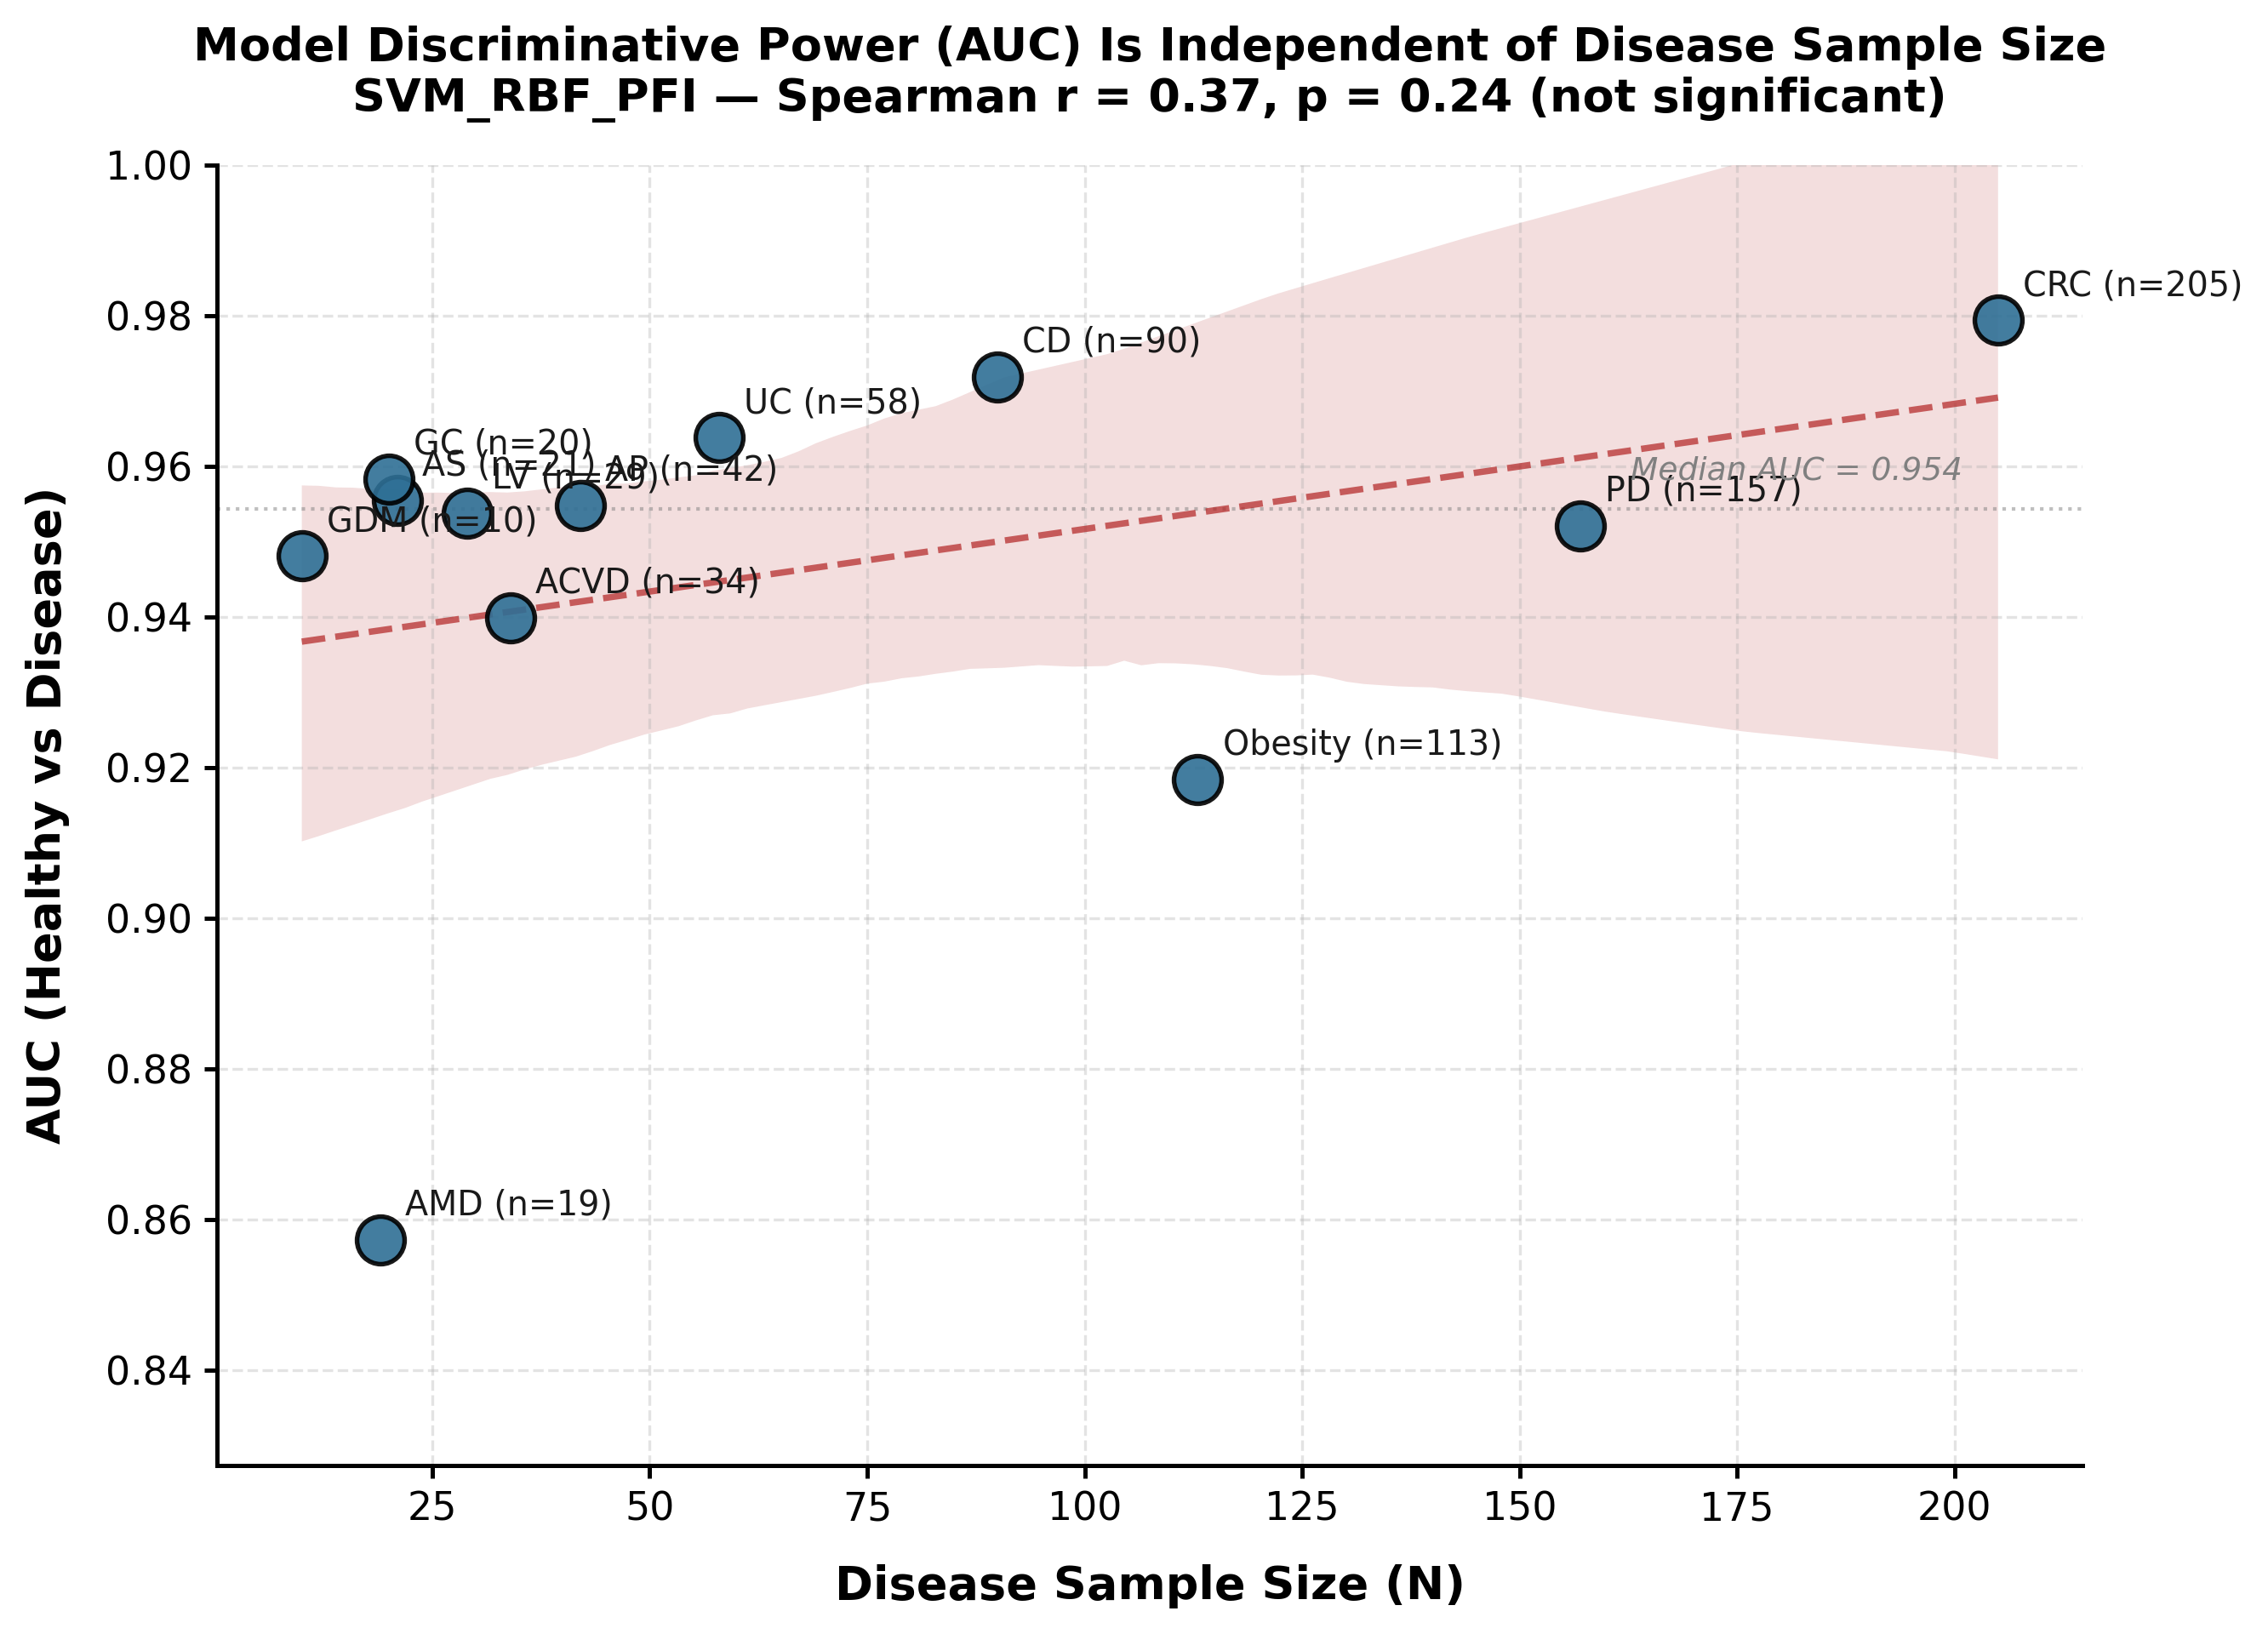

In [11]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

sns.regplot(
    data=performance, x="N_disease", y="AUC", ax=ax,
    scatter=False, ci=95,
    line_kws={'color': '#B22222', 'linestyle': '--', 'linewidth': 1.8, 'alpha': 0.7}
)

ax.scatter(
    performance["N_disease"], performance["AUC"],
    s=180, color="#2E6F95", edgecolor="black", linewidth=1.3,
    alpha=0.9, zorder=3
)

for _, row in performance.iterrows():
    ax.annotate(
        f"{row['Disease']} (n={int(row['N_disease'])})",
        (row["N_disease"], row["AUC"]),
        fontsize=9.5, fontweight='medium',
        xytext=(7, 7), textcoords='offset points',
        color='#1a1a1a'
    )

ax.set_xlabel("Disease Sample Size (N)", fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel("AUC (Healthy vs Disease)", fontsize=13, fontweight='bold', labelpad=10)
ax.set_title(
    f"Model Discriminative Power (AUC) Is Independent of Disease Sample Size\n"
    f"SVM_RBF_PFI — Spearman r = {corr_auc:.2f}, p = {pval_auc:.2f} (not significant)",
    fontsize=13, fontweight='bold', pad=15
)

ax.grid(True, linestyle='--', alpha=0.35, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

y_min = performance["AUC"].min() - 0.03
ax.set_ylim(bottom=y_min, top=1.0)

median_auc = performance["AUC"].median()
ax.axhline(median_auc, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
ax.text(
    performance["N_disease"].max() * 0.98, median_auc + 0.003,
    f"Median AUC = {median_auc:.3f}", fontsize=9, color='gray',
    ha='right', va='bottom', style='italic'
)

plt.tight_layout()
plt.savefig(f"AUC_vs_disease_sample_size_SVM_RBF_PFI_{prevalence}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"AUC_vs_disease_sample_size_SVM_RBF_PFI_{prevalence}.pdf", bbox_inches='tight')
plt.show()

## Summary

AUC — a threshold-independent, imbalance-robust metric — shows **no
significant correlation** with disease sample size (Spearman r, p reported
above). This supports the interpretation that the model captures a **shared,
generalizable dysbiosis signature** rather than being driven by disease
categories with larger representation in the dataset.